In [8]:
from stress_risk.behavior.utils import get_data
import seaborn as sns
#import pingouin
import numpy as np
import pandas as pd
import os.path as op
import matplotlib.pyplot as plt

plot_folder_path = '/Users/mrenke/Desktop/StressRisk/figures/plots/fig_1'
sns.set_context('talk')

df = get_data()
# rename for nice plot labels
df['group'] = np.where(df['group'] == 0, 'control', 'stress')
df['order'] = np.where(df['risky_first'] == True, 'risky first', 'safe first')



/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_30586/678374093.py:10: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  temp = df.groupby(['subject', x_name, 'order']).mean()
/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_30586/678374093.py:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 67)` for the same effect.

  sns.catplot(x=x_name, y=y_name, hue='order', data=temp.reset_index(), kind='point', ci=67, palette = 'husl')


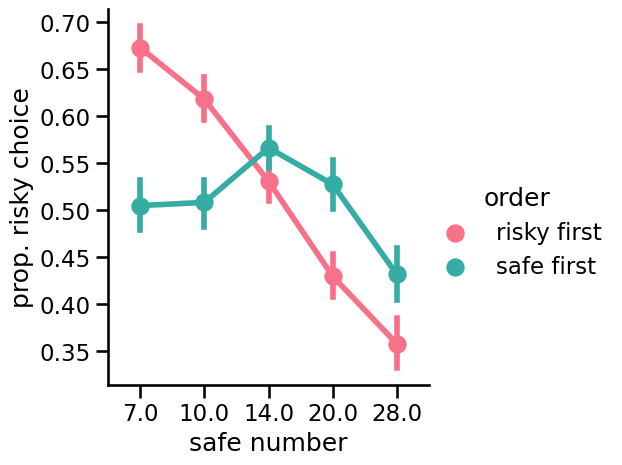

In [33]:
# plot raw behavior

y_name = 'prop. risky choice'
x_name = 'safe number'

df[x_name] = df['n_safe']
temp = df.groupby(['subject', x_name, 'order']).mean()
temp[y_name] = temp['chose_risky']
temp = temp[y_name].to_frame()

sns.catplot(x=x_name, y=y_name, hue='order', data=temp.reset_index(), kind='point', ci=67, palette = 'husl')
plt.savefig(op.join(plot_folder_path, f'order_range_rawData.png'))


In [ ]:
sns.set_context('talk')
# fac = sns.lmplot(x=x, y='chose_risky', data=df.reset_index(), logistic=True, col='group',hue='session') # 'risky_first'

df = df.sort_values('bin(risky/safe)')
fac = sns.catplot(x=x, y='chose_risky', data=df.reset_index(), col='group',hue='session', kind='point',
    errorbar='se',
    palette=sns.color_palette()[2:]) # 'risky_first'

for ax in fac.axes.ravel():
    ax.axhline(.5, c='k', ls='--')
    ax.axvline(2.5, c='k', ls='--')